In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import numpy as np

In [2]:
# ============================================
# 2) DATASET PATH
# ============================================

base_dir = r"C:\Users\alzai\Downloads\Dsce\chest_xray"

train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")
val_dir = os.path.join(base_dir, "val")

In [3]:
# ============================================
# 3) CHECK FOLDERS
# ============================================

print(os.listdir(base_dir))
print(os.listdir(train_dir))
print(os.listdir(test_dir))
print(os.listdir(val_dir))

['.ipynb_checkpoints', 'chest_xray', 'test', 'train', 'Untitled.ipynb', 'val', '__MACOSX']
['NORMAL', 'PNEUMONIA']
['NORMAL', 'PNEUMONIA']
['NORMAL', 'PNEUMONIA']


In [6]:
# ============================================
# 4) LOAD DATASET
# ============================================

train_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224,224),
    batch_size=32,
    label_mode='binary'
)

val_data = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(224,224),
    batch_size=32,
    label_mode='binary'
)

test_data = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224,224),
    batch_size=32,
    label_mode='binary',
    shuffle=False
)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


In [7]:
# ============================================
# SHOW CLASS NAMES
# ============================================

class_names = train_data.class_names

print(class_names)

['NORMAL', 'PNEUMONIA']


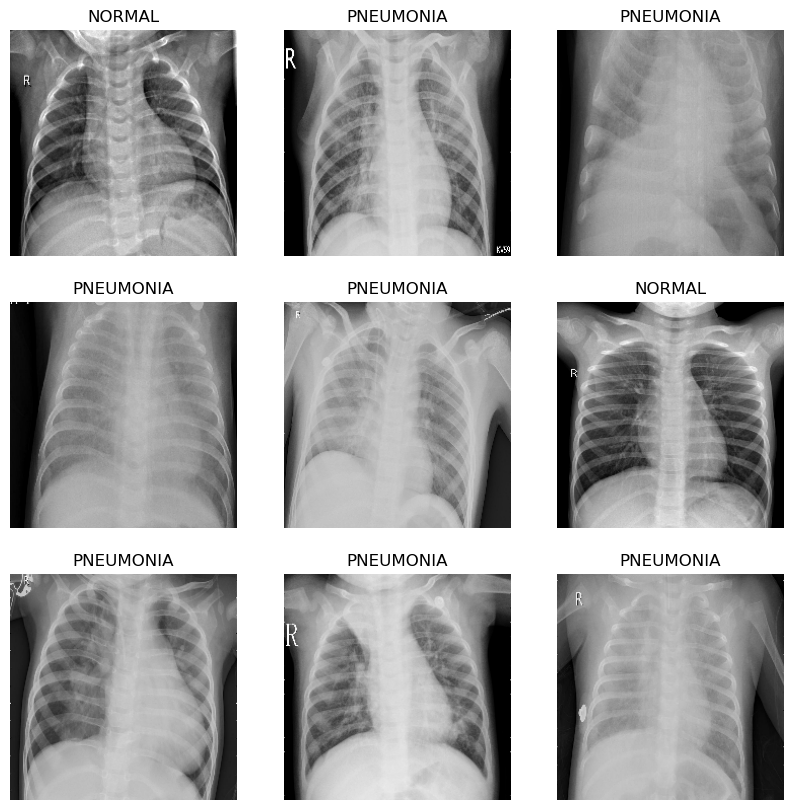

In [8]:
plt.figure(figsize=(10,10))

for images, labels in train_data.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"), cmap='gray')
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

plt.show()

In [8]:
# ============================================
# NORMALIZE DATA
# ============================================

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_data_norm = train_data.map(lambda x, y: (normalization_layer(x), y))
val_data_norm = val_data.map(lambda x, y: (normalization_layer(x), y))
test_data_norm = test_data.map(lambda x, y: (normalization_layer(x), y))

In [9]:
# ============================================
# BUILD CNN MODEL
# ============================================

model = tf.keras.models.Sequential([

    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [10]:
# ============================================
# COMPILE CNN MODEL
# ============================================

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [11]:
# ============================================
# MODEL SUMMARY
# ============================================

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 54, 54, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 26, 26, 128)       0

In [12]:
# ============================================
# TRAIN CNN MODEL
# ============================================

history = model.fit(
    train_data_norm,
    validation_data=val_data_norm,
    epochs=10
)

Epoch 1/10


163/163 [==============================] - 239s 1s/step - loss: 0.3544 - accuracy: 0.8740 - val_loss: 0.3430 - val_accuracy: 0.8125
Epoch 2/10
163/163 [==============================] - 106s 641ms/step - loss: 0.1383 - accuracy: 0.9471 - val_loss: 0.2816 - val_accuracy: 0.8750
Epoch 3/10
163/163 [==============================] - 133s 815ms/step - loss: 0.1242 - accuracy: 0.9534 - val_loss: 0.2858 - val_accuracy: 0.8125
Epoch 4/10
163/163 [==============================] - 185s 1s/step - loss: 0.0837 - accuracy: 0.9716 - val_loss: 0.2271 - val_accuracy: 0.8750
Epoch 5/10
163/163 [==============================] - 182s 1s/step - loss: 0.0751 - accuracy: 0.9741 - val_loss: 0.2450 - val_accuracy: 0.8750
Epoch 6/10
163/163 [==============================] - 206s 1s/step - loss: 0.0599 - accuracy: 0.9814 - val_loss: 0.1350 - val_accuracy: 0.9375
Epoch 7/10
163/163 [==============================] - 111s 667ms/step - loss: 0.0534 - accuracy: 0.9824 - val_loss: 0.1154 - val_accur

In [13]:
# ============================================
# EVALUATE CNN ON TEST DATA
# ============================================

test_loss, test_accuracy = model.evaluate(test_data_norm)

print("CNN Test Loss:", test_loss)
print("CNN Test Accuracy:", test_accuracy)

20/20 [==============================] - 6s 290ms/step - loss: 2.4768 - accuracy: 0.7324
CNN Test Loss: 2.4768314361572266
CNN Test Accuracy: 0.7323718070983887


In [14]:
# ============================================
# PREDICTIONS
# ============================================

y_pred = model.predict(test_data_norm)

y_pred = (y_pred > 0.5).astype(int)

20/20 [==============================] - 3s 121ms/step


In [15]:
# ============================================
# TRUE LABELS
# ============================================

y_true = np.concatenate([y for x, y in test_data_norm], axis=0)

In [16]:
# ============================================
# CLASSIFICATION REPORT
# ============================================

from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

      NORMAL       0.95      0.30      0.46       234
   PNEUMONIA       0.70      0.99      0.82       390

    accuracy                           0.73       624
   macro avg       0.82      0.65      0.64       624
weighted avg       0.79      0.73      0.69       624



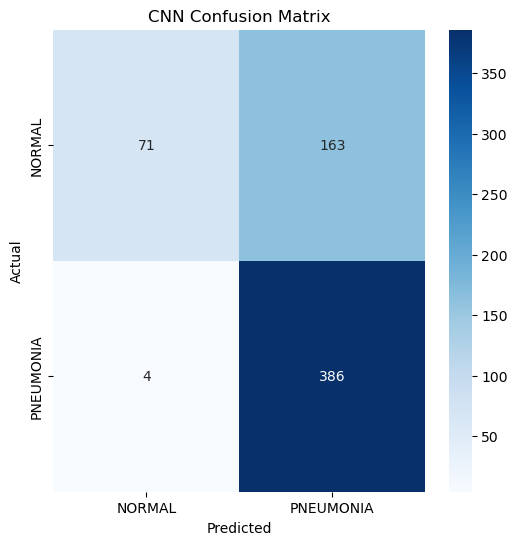

In [17]:
# ============================================
# CONFUSION MATRIX
# ============================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")

plt.show()

In [18]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [19]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

58889256/58889256 [==============================] - 31s 1us/step


In [20]:
vgg_model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [21]:
vgg_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [22]:
vgg_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 flatten_1 (Flatten)         (None, 25088)             0         
                                                                 
 dense_2 (Dense)             (None, 128)               3211392   
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_3 (Dense)             (None, 1)                 129       
                                                                 
Total params: 17926209 (68.38 MB)
Trainable params: 3211521 (12.25 MB)
Non-trainable params: 14714688 (56.13 MB)
_________________________________________________________________


In [23]:
history_vgg = vgg_model.fit(
    train_data_norm,
    validation_data=val_data_norm,
    epochs=10
)

Epoch 1/10
163/163 [==============================] - 540s 3s/step - loss: 0.2189 - accuracy: 0.9287 - val_loss: 0.3703 - val_accuracy: 0.8125
Epoch 2/10
163/163 [==============================] - 625s 4s/step - loss: 0.0868 - accuracy: 0.9688 - val_loss: 0.2162 - val_accuracy: 0.8750
Epoch 3/10
163/163 [==============================] - 534s 3s/step - loss: 0.0722 - accuracy: 0.9758 - val_loss: 0.4067 - val_accuracy: 0.8125
Epoch 4/10
163/163 [==============================] - 617s 4s/step - loss: 0.0621 - accuracy: 0.9781 - val_loss: 0.1662 - val_accuracy: 0.9375
Epoch 5/10
163/163 [==============================] - 713s 4s/step - loss: 0.0502 - accuracy: 0.9806 - val_loss: 0.1877 - val_accuracy: 0.9375
Epoch 6/10
163/163 [==============================] - 902s 6s/step - loss: 0.0484 - accuracy: 0.9827 - val_loss: 0.3047 - val_accuracy: 0.8750
Epoch 7/10
163/163 [==============================] - 883s 5s/step - loss: 0.0514 - accuracy: 0.9806 - val_loss: 0.2722 - val_accuracy: 0.8750

In [24]:
# ============================================
# EVALUATE VGG16 MODEL
# ============================================

vgg_test_loss, vgg_test_accuracy = vgg_model.evaluate(test_data_norm)

print("VGG16 Test Loss:", vgg_test_loss)
print("VGG16 Test Accuracy:", vgg_test_accuracy)

20/20 [==============================] - 43s 2s/step - loss: 1.6581 - accuracy: 0.7179
VGG16 Test Loss: 1.6581488847732544
VGG16 Test Accuracy: 0.7179487347602844


In [9]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [11]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

val_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [12]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

In [13]:
vgg_model = Sequential([

    base_model,

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(1, activation='sigmoid')

])

In [14]:
vgg_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [15]:
class_weight = {
    0: 2.0,
    1: 1.0
}

In [16]:
history_vgg_improved = vgg_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weight
)

Epoch 1/10


163/163 [==============================] - 477s 3s/step - loss: 0.4343 - accuracy: 0.8932 - val_loss: 0.4756 - val_accuracy: 0.7500
Epoch 2/10
163/163 [==============================] - 447s 3s/step - loss: 0.2418 - accuracy: 0.9302 - val_loss: 0.3616 - val_accuracy: 0.7500
Epoch 3/10
163/163 [==============================] - 447s 3s/step - loss: 0.2107 - accuracy: 0.9410 - val_loss: 0.2084 - val_accuracy: 0.8750
Epoch 4/10
163/163 [==============================] - 447s 3s/step - loss: 0.2012 - accuracy: 0.9408 - val_loss: 0.3165 - val_accuracy: 0.7500
Epoch 5/10
163/163 [==============================] - 446s 3s/step - loss: 0.2025 - accuracy: 0.9454 - val_loss: 0.3134 - val_accuracy: 0.8125
Epoch 6/10
163/163 [==============================] - 450s 3s/step - loss: 0.1745 - accuracy: 0.9515 - val_loss: 0.2602 - val_accuracy: 0.8125
Epoch 7/10
163/163 [==============================] - 455s 3s/step - loss: 0.1730 - accuracy: 0.9492 - val_loss: 0.1607 - val_accuracy: 0.93

In [17]:
# ============================================
# EVALUATE IMPROVED VGG16
# ============================================

improved_loss, improved_accuracy = vgg_model.evaluate(test_generator)

print("Improved VGG16 Test Loss:", improved_loss)
print("Improved VGG16 Test Accuracy:", improved_accuracy)

20/20 [==============================] - 43s 2s/step - loss: 0.3976 - accuracy: 0.8782
Improved VGG16 Test Loss: 0.3975827693939209
Improved VGG16 Test Accuracy: 0.8782051205635071


In [18]:
# ============================================
# PREDICTIONS
# ============================================

improved_pred = vgg_model.predict(test_generator)

improved_pred = (improved_pred > 0.5).astype(int)

20/20 [==============================] - 49s 2s/step


In [19]:
improved_pred = vgg_model.predict(test_generator)
improved_pred = (improved_pred > 0.5).astype(int)

from sklearn.metrics import classification_report

y_true = test_generator.classes

print(classification_report(
    y_true,
    improved_pred,
    target_names=['NORMAL', 'PNEUMONIA']
))

20/20 [==============================] - 42s 2s/step
              precision    recall  f1-score   support

      NORMAL       0.99      0.68      0.81       234
   PNEUMONIA       0.84      0.99      0.91       390

    accuracy                           0.88       624
   macro avg       0.91      0.84      0.86       624
weighted avg       0.90      0.88      0.87       624



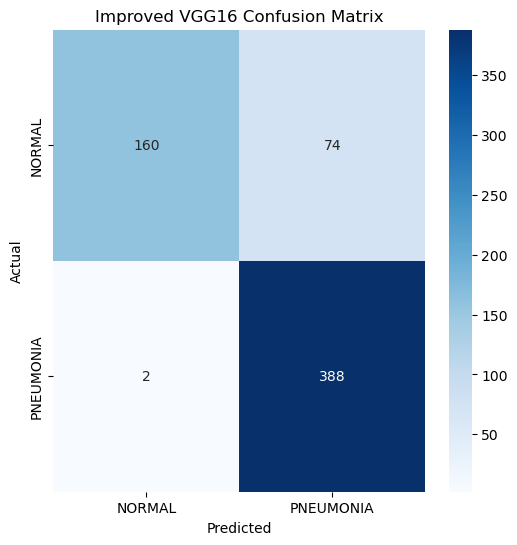

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, improved_pred)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['NORMAL', 'PNEUMONIA'],
    yticklabels=['NORMAL', 'PNEUMONIA']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Improved VGG16 Confusion Matrix")

plt.show()

1/1 [==============================] - 1s 609ms/step


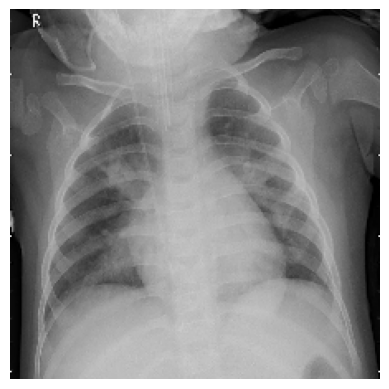

Result: PNEUMONIA
Confidence: 0.9952556


In [21]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = r"C:\Users\alzai\Downloads\Dsce\person9_bacteria_39.jpeg"

img = image.load_img(img_path, target_size=(224,224))

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = vgg_model.predict(img_array)[0][0]

plt.imshow(img)
plt.axis("off")
plt.show()

if prediction >= 0.5:
    print("Result: PNEUMONIA")
else:
    print("Result: NORMAL")

print("Confidence:", prediction)

1/1 [==============================] - 0s 126ms/step


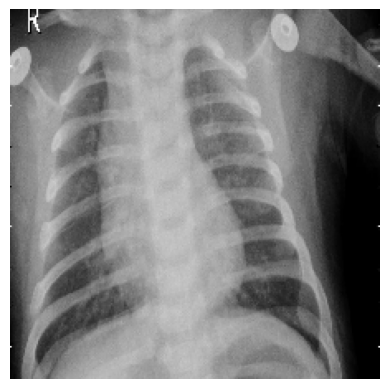

Result: PNEUMONIA
Confidence: 0.99919367


In [24]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = r"C:\Users\alzai\Downloads\Dsce\chest125.jpeg"

img = image.load_img(img_path, target_size=(224,224))

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = vgg_model.predict(img_array)[0][0]

plt.imshow(img)
plt.axis("off")
plt.show()

if prediction >= 0.5:
    print("Result: PNEUMONIA")
else:
    print("Result: NORMAL")

print("Confidence:", prediction)

1/1 [==============================] - 0s 128ms/step


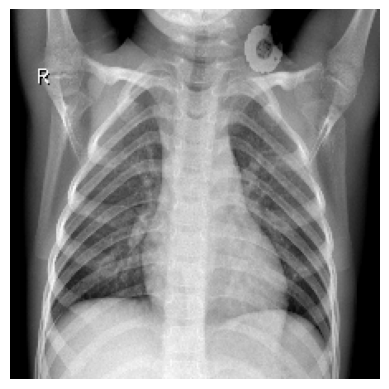

Result: NORMAL
Confidence: 0.00032413227


In [25]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = r"C:\Users\alzai\Downloads\Dsce\chest1288.jpeg"

img = image.load_img(img_path, target_size=(224,224))

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = vgg_model.predict(img_array)[0][0]

plt.imshow(img)
plt.axis("off")
plt.show()

if prediction >= 0.5:
    print("Result: PNEUMONIA")
else:
    print("Result: NORMAL")

print("Confidence:", prediction)

1/1 [==============================] - 0s 136ms/step


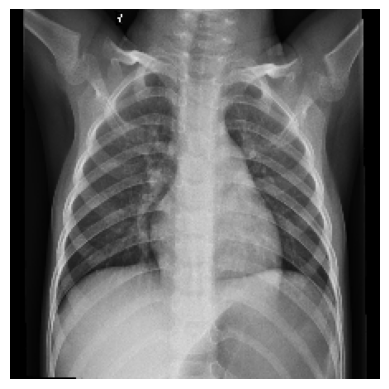

Result: NORMAL
Confidence: 0.002564564


In [26]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = r"C:\Users\alzai\Downloads\Dsce\chest1128888.jpeg"

img = image.load_img(img_path, target_size=(224,224))

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = vgg_model.predict(img_array)[0][0]

plt.imshow(img)
plt.axis("off")
plt.show()

if prediction >= 0.5:
    print("Result: PNEUMONIA")
else:
    print("Result: NORMAL")

print("Confidence:", prediction)

In [28]:
vgg_model.save("improved_vgg16_model.keras")

In [29]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'chest_xray', 'improved_vgg16_model.h5', 'improved_vgg16_model.keras', 'test', 'train', 'Untitled.ipynb', 'val', '__MACOSX']
